# Diluted AXIAL current validation (`jj_corr_dilute`, exact-K axial $C_{A+-}$)

Stochastic axial sibling of `jj_dilute_validate_claude.ipynb`.  Validates the diluted exact-K **axial**
correlator (`h0/axial/{tp,sp}/Apm`, master-field superposed + 4-pattern diluted) against the deterministic
single-insertion ground truth `corr_deter_exact1_axial_L1` (`h0/t0_0/{tp,sp}/Apm`).

**Symmetry (`jj_symmetries_masscases_claude.md`, massless):** the axial $C_{A+-}$ is **complex with NO
reality** -- the only exact relation is the *channel* reflection $C_{A+-}(\Delta t)=C_{A-+}(-\Delta t)$
(Eq. 3.56); it reflects onto the *other* channel, not itself.  So we **cannot** four-fold-fold (no
self-reflection).  We only apply the master-field **half-volume shift** (the superposed correlator has
period $N_t/2$: $C(t)=G(t)+G(t-N_t/2)$, $C(t)=C(t+N_t/2)$) -> average the two period images onto
$0\le t\le N_t/2$.  We plot **both Re and Im** (no reality), and the comparison is made on the **first
(forward) branch** (small $t$, where $C\approx G(t)$); agreement there in both Re and Im is sufficient.

The dilute axial = area-weighted SUM (Eq. 4.29); exact1 = single insertion -> they differ by a single REAL
constant per channel (the geometric sum factor, $\approx 1/4\pi$ at $L{=}1$), fixed by matching at a ref.

In [1]:
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt

In [22]:
##### ----- config -----
dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
# ----- mass switch: 'massless' | 'mF' (m=0.1 real) | 'mP' (m=0.1i imag).  Only ESN changes per mass. -----
MASS = 'mP'
_ESN = {'massless':'data_free_vmRe0.000000vmIm0.000000/',
        'mF':      'data_free_vmRe0.100000vmIm0.000000/',
        'mP':      'data_free_vmRe0.000000vmIm0.100000/'}
ESN  = dir1 + _ESN[MASS]
at_cft = 0.2; Nt_cft = 128
DIL  = 'corr_dil_nt02_nhits140_s1td2'  # 140-hit validation run (spin x e/o-time dilution = 4 patterns/hit)
EXS1 = 'corr_deter_exact1_axial_L1'    # deterministic exact-K axial ground truth (single insertion, t0_0)

# ----- diluted AXIAL loaders: per-hit files, keys h0/axial/<proj>/Apm (superposed, complex) -----
def dil_files(dirn):
    out=[]
    for f in sorted(glob.glob(ESN+dirn+'/corr.0.h*.h5')):
        with h5py.File(f,'r') as h:
            if 'complete' in h: out.append(f)
    return out
def dil_axial(dirn, proj):              # proj 'tp'/'sp' -> (nhits, Nt) complex
    out=[]
    for f in dil_files(dirn):
        with h5py.File(f,'r') as h:
            k='h0/axial/'+proj+'/Apm'
            out.append(h[k+'/real'][()] + 1j*h[k+'/imag'][()])
    assert out, 'no complete diluted hits in %s' % dirn
    return np.array(out)
def det_axial(corrdir, proj):           # exact1 single-origin -> (Nt,) complex
    with h5py.File(ESN+corrdir+'/corr.0.h5','r') as f:
        k='h0/t0_0/'+proj+'/Apm'
        return f[k+'/real'][()] + 1j*f[k+'/imag'][()]

# ----- master-field HALF-VOLUME shift (the only allowed operation for the axial: NO T-reflection fold) -----
# The diluted C(t) is already the master-field combination G(t)+G(t-Nt/2) (two superposed origins 0, Nt/2).
# The single-origin determ G(dt) is put in the SAME form by the half-volume shift mirror() = G + roll(G,Nt/2).
# We then plot the FULL [0,Nt) (axial is only 2-fold; validation needs only the first half 0<t<Nt/2).
def mirror(G):
    return G + np.roll(G, len(G)//2)

# ----- Nt/2-shift AVERAGING (the master-field has period Nt/2: C(t) and C(t+Nt/2) carry the SAME signal
# but independent stochastic noise -> averaging the two translated copies keeps the mean, cuts the error
# ~1/sqrt(2)).  This is a TRANSLATION average, NOT a reflection fold (axial has no T-reflection symmetry).
def half_shift_avg(C):
    return 0.5*(C + np.roll(C, C.shape[-1]//2, axis=-1))

# ----- jackknife over hits for a COMPLEX (nhits,M) array -> (mean, err_re, err_im) -----
def jk_cplx(arr):
    H=len(arr); s=arr.sum(0)
    samp=np.array([(s-arr[i])/(H-1) for i in range(H)])
    est=samp.mean(0)
    vre=(H-1)*np.mean((samp.real-est.real)**2,0); vim=(H-1)*np.mean((samp.imag-est.imag)**2,0)
    return est, np.sqrt(vre), np.sqrt(vim)

# folded diluted (jk) + folded determ + the real matching constant c (summed-vs-single), per channel.
# ONE common normalization for BOTH channels (NO per-channel ref fit): the diluted is the area-weighted
# SUM with 1/4pi, the determ exact1 is a single insertion (w=1), so at L=1 the ratio is EXACTLY 1/4pi for
# tp and sp alike (mass-independent geometric factor -> same c for massless/mF/mP).
CFAC = 1.0/(4.0*np.pi)
def prep(proj):
    # AXIAL is only TWO-fold (master-field period Nt/2; NO reflection -> no four-fold).  Apply the Nt/2-shift
    # AVERAGING (half_shift_avg: average C(t) with C(t+Nt/2); mean kept, stoch noise ~/sqrt2).  Plot FULL [0,Nt)
    # (now Nt/2-periodic, both halves identical); validation needs only 0<t<Nt/2.
    A = dil_axial(DIL, proj)                                      # (nhits, Nt) complex
    A = half_shift_avg(A)                                        # Nt/2-shift averaging (mean kept, noise ~/sqrt2)
    m, ere, eim = jk_cplx(A)
    d = half_shift_avg(mirror(det_axial(EXS1, proj)))           # determ master-field form (avg = no-op: Nt/2-periodic)
    return m, ere, eim, d, CFAC                                   # SAME const for tp and sp

print('MASS=%s  ESN=%s' % (MASS, _ESN[MASS]))
print('diluted hits:', len(dil_files(DIL)))
for p in ['tp','sp']:
    m,ere,eim,d,c = prep(p)
    print('%s: match c = %.4f (expect ~1/4pi=%.4f)' % (p, c, 1.0/(4*np.pi)))

# ----- LOCAL AXIAL loaders (NEW: h0/axial/s{c}/Apm in the dilute; determ corr_deter_local_axial_L1) -----
LOCAX = 'corr_deter_local_axial_L1'
def dil_loc_axial(cc):                  # diluted local axial s{cc} -> (nhits, Nt) complex, or None if absent
    out=[]
    for f in dil_files(DIL):
        with h5py.File(f,'r') as h:
            k='h0/axial/s%d/Apm'%cc
            if (k+'/real') not in h: return None
            out.append(h[k+'/real'][()] + 1j*h[k+'/imag'][()])
    return np.array(out) if out else None
def det_loc_axial(cc):                  # determ local axial s{cc}, single origin
    with h5py.File(ESN+LOCAX+'/corr.0.h5','r') as f:
        k='h0/t0_0/s%d/Apm'%cc
        return f[k+'/real'][()] + 1j*f[k+'/imag'][()]

MASS=mP  ESN=data_free_vmRe0.000000vmIm0.100000/
diluted hits: 11
tp: match c = 0.0796 (expect ~1/4pi=0.0796)
sp: match c = 0.0796 (expect ~1/4pi=0.0796)


In [23]:
# ----- mass labels: title tag ($m=...$) + savefig filename tag (keyed by MASS) -----
_MLAB = {'massless':'m0', 'mF':'m0.1', 'mP':'m0.1i'}; MLAB = _MLAB[MASS]
_MTIT = {'massless':'0',  'mF':'0.1',  'mP':'0.1i'};  MTIT = _MTIT[MASS]
# ----- all figures saved under figs/ -----
import os
FIGDIR = 'figs'; os.makedirs(FIGDIR, exist_ok=True)

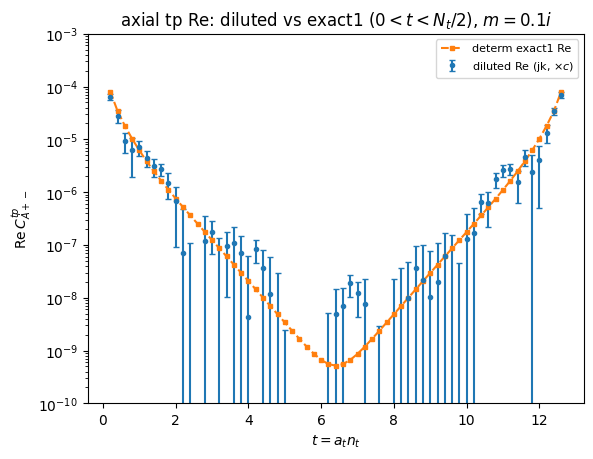

In [24]:
# AXIAL tp -- REAL part, independent region 0<t<Nt/2 (Nt/2-periodic after shift-avg).  diluted (jk, x c) vs determ exact1.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m, ere, eim, d, c = prep('tp')
plt.figure()
plt.errorbar(t, (c*m).real[dt], yerr=c*ere[dt], fmt='o', ms=3, capsize=2, label='diluted Re (jk, $\\times c$)')
plt.plot(t, d.real[dt], 's--', ms=3, label='determ exact1 Re')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$\mathrm{Re}\,C_{A+-}^{tp}$')

plt.ylim(1.0e-10,1.0e-3)
plt.yscale("log")

plt.title('axial tp Re: diluted vs exact1 ($0<t<N_t/2$), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/jj_dilute_axial_tp_re_'+MLAB+'.pdf', bbox_inches='tight')

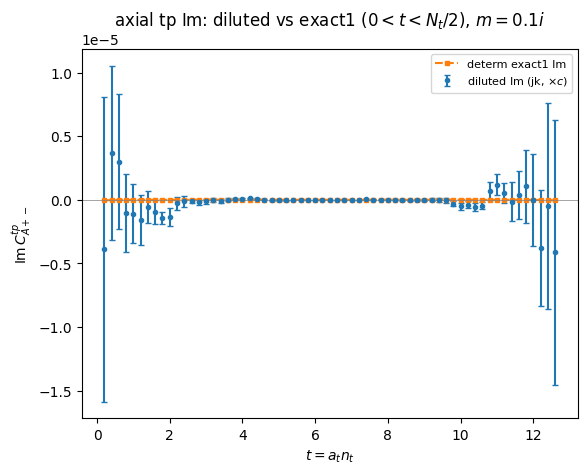

In [25]:
# AXIAL tp -- IMAG part, 0<t<Nt/2.  (axial has no reality -> Im is physical, must also match.)
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m, ere, eim, d, c = prep('tp')
plt.figure()
plt.errorbar(t, (c*m).imag[dt], yerr=c*eim[dt], fmt='o', ms=3, capsize=2, label='diluted Im (jk, $\\times c$)')
plt.plot(t, d.imag[dt], 's--', ms=3, label='determ exact1 Im')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$\mathrm{Im}\,C_{A+-}^{tp}$')
plt.title('axial tp Im: diluted vs exact1 ($0<t<N_t/2$), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/jj_dilute_axial_tp_im_'+MLAB+'.pdf', bbox_inches='tight')

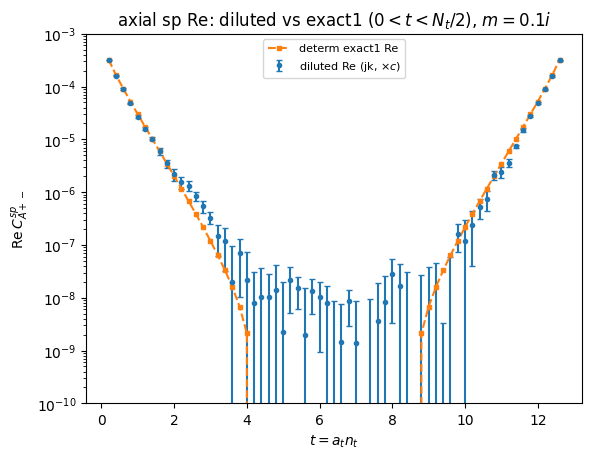

In [26]:
# AXIAL sp -- REAL part, 0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m, ere, eim, d, c = prep('sp')
plt.figure()
plt.errorbar(t, (c*m).real[dt], yerr=c*ere[dt], fmt='o', ms=3, capsize=2, label='diluted Re (jk, $\\times c$)')
plt.plot(t, d.real[dt], 's--', ms=3, label='determ exact1 Re')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$\mathrm{Re}\,C_{A+-}^{sp}$')

plt.ylim(1.0e-10,1.0e-3)
plt.yscale("log")

plt.title('axial sp Re: diluted vs exact1 ($0<t<N_t/2$), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/jj_dilute_axial_sp_re_'+MLAB+'.pdf', bbox_inches='tight')

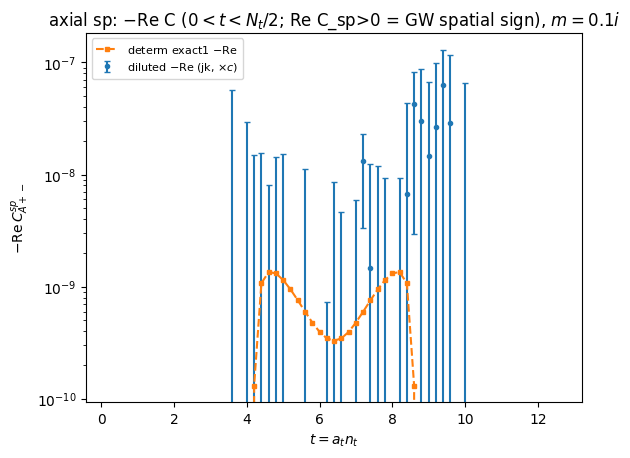

In [27]:
# AXIAL sp -- -Re C, LINEAR axis (the exact axial sp Re is POSITIVE = the coarse-L GW spatial sign, so
# -Re C_sp is NEGATIVE -> a log axis would be empty; shown here on a linear axis).  diluted (x c) vs determ.
# To instead read the exponential decay, plot +Re C_sp on log (the sp Re cell above, with yscale('log')).
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m, ere, eim, d, c = prep('sp')
plt.figure()
plt.errorbar(t, -(c*m).real[dt], yerr=c*ere[dt], fmt='o', ms=3, capsize=2, label='diluted $-$Re (jk, $\\times c$)')
plt.plot(t, -d.real[dt], 's--', ms=3, label='determ exact1 $-$Re')
plt.axhline(0, color='gray', lw=0.5)

plt.yscale("log")

plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$-\mathrm{Re}\,C_{A+-}^{sp}$')
plt.title('axial sp: $-$Re C ($0<t<N_t/2$; Re C_sp>0 = GW spatial sign), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/jj_dilute_axial_sp_negre_'+MLAB+'.pdf', bbox_inches='tight')

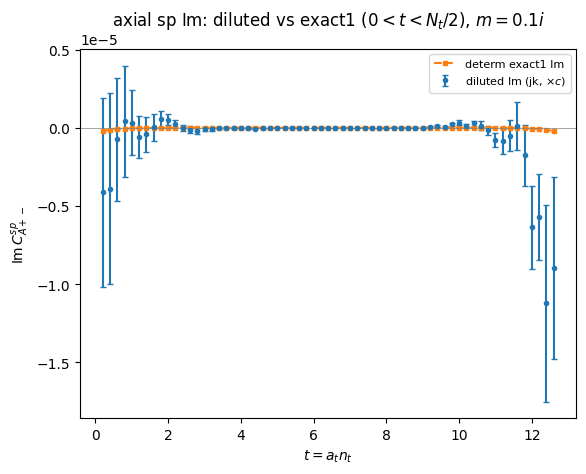

In [28]:
# AXIAL sp -- IMAG part, 0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
m, ere, eim, d, c = prep('sp')
plt.figure()
plt.errorbar(t, (c*m).imag[dt], yerr=c*eim[dt], fmt='o', ms=3, capsize=2, label='diluted Im (jk, $\\times c$)')
plt.plot(t, d.imag[dt], 's--', ms=3, label='determ exact1 Im')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$\mathrm{Im}\,C_{A+-}^{sp}$')
plt.title('axial sp Im: diluted vs exact1 ($0<t<N_t/2$), $m='+MTIT+'$'); plt.legend(fontsize=8)
plt.savefig(FIGDIR+'/jj_dilute_axial_sp_im_'+MLAB+'.pdf', bbox_inches='tight')

In [29]:
# Summary @ a few dt in the first branch: diluted (xc) vs determ, Re and Im, both channels.
for proj in ['tp','sp']:
    m, ere, eim, d, c = prep(proj)
    print('=== axial %s (match c=%.4f) ===' % (proj, c))
    print(' dt   Re: dil+-err          det          | Im: dil+-err          det')
    for dt in [1,3,5,8,12]:
        print(' %2d   % .3e+-%.1e  % .3e | % .3e+-%.1e  % .3e' % (
            dt, (c*m).real[dt], c*ere[dt], d.real[dt], (c*m).imag[dt], c*eim[dt], d.imag[dt]))

=== axial tp (match c=0.0796) ===
 dt   Re: dil+-err          det          | Im: dil+-err          det
  1    6.365e-05+-7.1e-06   8.035e-05 | -3.894e-06+-1.2e-05  -4.591e-08
  3    9.326e-06+-3.9e-06   1.807e-05 |  3.004e-06+-5.3e-06  -1.400e-08
  5    7.041e-06+-2.2e-06   6.154e-06 | -1.084e-06+-2.3e-06  -7.477e-09
  8    2.736e-06+-7.1e-07   1.640e-06 | -9.897e-07+-9.5e-07  -3.322e-09
 12   -2.682e-07+-3.8e-07   3.618e-07 | -1.306e-07+-4.2e-07  -1.066e-09
=== axial sp (match c=0.0796) ===
 dt   Re: dil+-err          det          | Im: dil+-err          det
  1    3.158e-04+-3.9e-06   3.212e-04 | -4.128e-06+-6.0e-06  -2.111e-07
  3    9.047e-05+-3.3e-06   9.166e-05 | -7.202e-07+-3.9e-06  -7.848e-08
  5    2.676e-05+-1.6e-06   2.994e-05 |  3.413e-07+-2.0e-06  -3.078e-08
  8    5.918e-06+-8.2e-07   5.927e-06 |  3.997e-08+-8.7e-07  -7.759e-09
 12    1.317e-06+-2.8e-07   6.725e-07 | -1.808e-09+-1.7e-07  -1.192e-09


In [ ]:
# LOCAL AXIAL s3 (the G_t-analog channel): diluted (jk) vs determ corr_deter_local_axial, Re, 0<t<Nt/2.
# Diluted summed (area-weight+1/4pi) and determ summed are the SAME normalization -> DIRECT compare (no const);
# determ mirror'd to the master-field form.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft
plt.figure()
A = dil_loc_axial(3)
if A is None:
    print('no diluted local axial yet -- rerun jj_corr_dilute (rm old hits first)')
else:
    A = half_shift_avg(A)                                       # Nt/2-shift averaging
    m,ere,eim = jk_cplx(A)
    plt.errorbar(t, m.real[dt], yerr=ere[dt], fmt='o', ms=3, capsize=2, label='diluted local s3 Re (jk)')
    d = half_shift_avg(mirror(det_loc_axial(3)))
    plt.plot(t, d.real[dt], 's--', ms=3, label='determ local axial s3 Re')
    plt.axhline(0,color='gray',lw=0.5); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$\mathrm{Re}$ local axial $s_3$')
    plt.title('local axial s3: diluted vs determ (Re, $0<t<N_t/2$), $m='+MTIT+'$'); plt.legend(fontsize=8)
    plt.ylim(1e-8, 0.1)
    plt.yscale("log")
    plt.savefig(FIGDIR+'/jj_dilute_axial_local_s3_'+MLAB+'.pdf', bbox_inches='tight')

In [ ]:
# LOCAL AXIAL ratio (s1+s2)/2 / s3 (as in the vector local).  diluted (jk) vs determ.  0<t<Nt/2.
dt = np.arange(1, Nt_cft//2); t = dt*at_cft; ref = 8
A1,A2,A3 = dil_loc_axial(1), dil_loc_axial(2), dil_loc_axial(3)
if A1 is None:
    print('no diluted local axial yet -- rerun jj_corr_dilute (rm old hits first)')
else:
    A1,A2,A3 = half_shift_avg(A1), half_shift_avg(A2), half_shift_avg(A3)   # Nt/2-shift averaging
    num = 0.5*(A1+A2)
    rn,_,_ = jk_cplx(num); rd,_,_ = jk_cplx(A3)
    plt.figure()
    plt.plot(t, (rn.real/rd.real)[dt], 'o', ms=3, label='diluted local (s1+s2)/2 / s3')
    d1,d2,d3 = half_shift_avg(mirror(det_loc_axial(1))),half_shift_avg(mirror(det_loc_axial(2))),half_shift_avg(mirror(det_loc_axial(3)))
    plt.plot(t, ((0.5*(d1+d2)).real/d3.real)[dt], 's--', ms=3, label='determ local axial')
    plt.axhline(-1.0,color='k',lw=1,label='-1'); plt.ylim(-3,1)
    plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$(s_1{+}s_2)/(2 s_3)$ local axial')
    plt.title('local axial ratio ($0<t<N_t/2$), $m='+MTIT+'$'); plt.legend(fontsize=8)
    plt.savefig(FIGDIR+'/jj_dilute_axial_local_ratio_'+MLAB+'.pdf', bbox_inches='tight')